In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

o:\Hackthons\KrishiOS\ai


In [2]:
import json
import time

import torch
import matplotlib.pyplot as plt

from PIL import Image

from torchvision import transforms

from configs.config import *

from training.model import build_model
print("✅ Libraries Loaded")

✅ Libraries Loaded


In [3]:
model = build_model(NUM_CLASSES)

checkpoint = torch.load(
    PROJECT_ROOT / "models" / "best_model.pth",
    map_location=DEVICE,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)

model.eval()

print("✅ Model Loaded")

✅ Model Loaded


In [4]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder(TRAIN_DIR)

class_names = dataset.classes

print(class_names[:5])

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [5]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    ),
])

In [6]:
def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    input_tensor = transform(image)

    input_tensor = input_tensor.unsqueeze(0)

    input_tensor = input_tensor.to(DEVICE)

    with torch.no_grad():

        outputs = model(input_tensor)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, prediction = torch.max(
            probabilities,
            dim=1,
        )

    return (
        image,
        prediction.item(),
        confidence.item(),
        probabilities.squeeze(),
    )

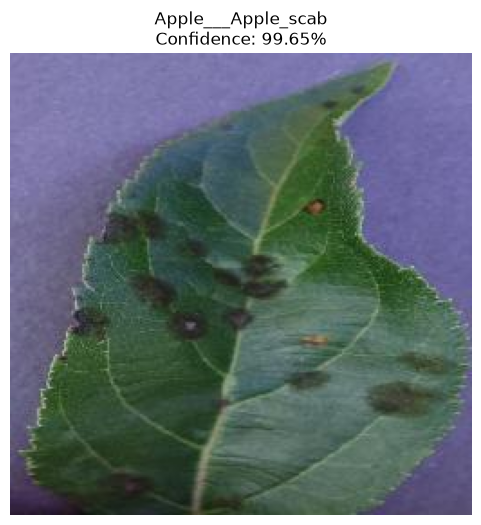

In [7]:
IMAGE_PATH = TRAIN_DIR / class_names[0]

sample_image = list(IMAGE_PATH.glob("*"))[0]

image, pred, confidence, probs = predict_image(sample_image)

plt.figure(figsize=(6,6))

plt.imshow(image)

plt.axis("off")

plt.title(
    f"{class_names[pred]}\nConfidence: {confidence:.2%}"
)

plt.show()

In [8]:
top5_prob, top5_idx = torch.topk(
    probs,
    k=5,
)

print("Top 5 Predictions\n")

for idx, prob in zip(top5_idx, top5_prob):

    print(
        f"{class_names[idx]} : {prob:.2%}"
    )

Top 5 Predictions

Apple___Apple_scab : 99.65%
Peach___Bacterial_spot : 0.28%
Pepper,_bell___healthy : 0.03%
Apple___Cedar_apple_rust : 0.01%
Grape___Black_rot : 0.01%


In [9]:
folder = TRAIN_DIR / class_names[0]

images = list(folder.glob("*"))[:5]

for img in images:

    _, pred, conf, _ = predict_image(img)

    print(
        img.name,
        "->",
        class_names[pred],
        f"{conf:.2%}",
    )

01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG -> Apple___Apple_scab 99.65%
01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Scab 3112.JPG -> Apple___Apple_scab 99.30%
0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Scab 3037.JPG -> Apple___Apple_scab 83.06%
023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Scab 3487.JPG -> Apple___Apple_scab 99.92%
0261a6e4-21f8-481a-8827-b674e6955644___FREC_Scab 3055.JPG -> Apple___Apple_scab 100.00%


In [10]:
start = time.perf_counter()

predict_image(sample_image)

end = time.perf_counter()

print(
    f"Inference Time: {(end-start)*1000:.2f} ms"
)

Inference Time: 16.47 ms


In [11]:
result = {

    "prediction": class_names[pred],

    "confidence": float(confidence),

}

with open(
    PROJECT_ROOT / "outputs" / "prediction.json",
    "w",
) as f:

    json.dump(
        result,
        f,
        indent=4,
    )

print("Prediction saved.")

Prediction saved.


In [13]:
print("=" * 60)
print("Inference Complete")
print("Model Ready for API Integration")

Inference Complete
Model Ready for API Integration
